![image.png](https://i.imgur.com/a3uAqnb.png)


# Image Colorization

## Use case
**Goal.** Given a single-channel **grayscale** image, predict a plausible **full-color (RGB)** version of the same scene. This is the classic *image colorization* problem: a one-to-many mapping where the model learns realistic color priors (sky is blue, grass is green, skin tones, etc.) from paired examples.

**Why it matters.** Restoring old black-and-white photos and film, colorizing medical/satellite/infrared captures for easier human interpretation, and as a self-supervised pretext task for representation learning.



```
data/
├── train_black/   # grayscale training inputs   (X)
├── train_color/   # color training targets      (y)
├── test_black/    # grayscale test inputs        (X)
└── test_color/    # color test targets           (y)
```

Each grayscale image has a **same-named** color counterpart. Images are ~400×400 and are resized here to a fixed square for batching.


## 1. Imports & configuration

In [1]:
import os
import glob
import random

import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import torchvision.transforms as T
import matplotlib.pyplot as plt

# ---- Config: edit only IMG_SIZE / BATCH_SIZE if needed ----
IMG_SIZE   = 224          # square resize (HxW) for batching
BATCH_SIZE = 16
NUM_WORKERS = 2
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

print("torch:", torch.__version__, "| CUDA available:", torch.cuda.is_available())

torch: 2.11.0+cpu | CUDA available: False


## 2. Locate the dataset



In [8]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aayush9753/image-colorization-dataset")
print("Path to dataset files:", path)

EXPECTED = ["train_black", "train_color", "test_black", "test_color"]

def find_data_root(base):
    """Find the folder under `base` that directly contains the four expected subfolders."""
    candidates = [base, os.path.join(base, "data")] + glob.glob(os.path.join(base, "*"))
    for root in candidates:
        if os.path.isdir(root) and all(os.path.isdir(os.path.join(root, d)) for d in EXPECTED):
            return os.path.abspath(root)
    return None

DATA_ROOT = find_data_root(path)
if DATA_ROOT is None:
    raise FileNotFoundError(
        f"Downloaded to {path}, but couldn't find the four folders {EXPECTED}. "
        "Inspect the download with: os.listdir(path)"
    )

TRAIN_BLACK = os.path.join(DATA_ROOT, "train_black")
TRAIN_COLOR = os.path.join(DATA_ROOT, "train_color")
TEST_BLACK  = os.path.join(DATA_ROOT, "test_black")
TEST_COLOR  = os.path.join(DATA_ROOT, "test_color")

print("DATA_ROOT:", DATA_ROOT)

Using Colab cache for faster access to the 'image-colorization-dataset' dataset.
Path to dataset files: /kaggle/input/image-colorization-dataset
DATA_ROOT: /kaggle/input/image-colorization-dataset/data


## 3. Validate the grayscale ↔ color pairing

The model needs aligned `(gray, color)` pairs. We match by **filename** and assert that the black and color folders contain exactly the same set of names. Any mismatch is surfaced here rather than producing misaligned training pairs later.

In [10]:
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def list_images(folder):
    names = [f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS)]
    return sorted(names)

def paired_names(black_dir, color_dir, split_name):
    black = set(list_images(black_dir))
    color = set(list_images(color_dir))

    only_black = black - color
    only_color = color - black
    common = sorted(black & color)

    print(f"[{split_name}] gray={len(black)}  color={len(color)}  paired={len(common)}")
    if only_black:
        print(f"  ! {len(only_black)} gray images have no color match (e.g. {sorted(only_black)[:3]})")
    if only_color:
        print(f"  ! {len(only_color)} color images have no gray match (e.g. {sorted(only_color)[:3]})")

    if len(common) == 0:
        raise RuntimeError(f"[{split_name}] No paired images found — check folder contents.")
    return common

train_names = paired_names(TRAIN_BLACK, TRAIN_COLOR, "train")
test_names  = paired_names(TEST_BLACK,  TEST_COLOR,  "test")

[train] gray=5000  color=5000  paired=5000
[test] gray=739  color=739  paired=739


## 4. `ColorizationDataset`

Each item returns a `(gray, color)` tensor pair:

- **gray** — shape `[1, H, W]`, values in `[0, 1]` → the model **input**.
- **color** — shape `[3, H, W]`, values in `[0, 1]` → the **target**.

The grayscale image is read from `*_black` and forced to 1 channel; the target is read from `*_color` as RGB. Both are resized to the same `IMG_SIZE` so they stay pixel-aligned.

> Note: this dataset already provides explicit grayscale files, so we read them directly.

In [22]:
class ColorizationDataset(Dataset):
    def __init__(self, names, black_dir, color_dir, img_size=IMG_SIZE):
        self.names = names
        self.black_dir = black_dir
        self.color_dir = color_dir
        self.gray_tf = T.Compose([
            T.Resize((img_size, img_size)),
            T.Grayscale(num_output_channels=1),  # enforce single channel
            T.ToTensor(),                         # -> [1, H, W] in [0,1]
        ])
        self.color_tf = T.Compose([
            T.Resize((img_size, img_size)),
            T.ToTensor(),                         # -> [3, H, W] in [0,1]
        ])

    def __len__(self):
        return len(self.names)

    def __getitem__(self, idx):
        name = self.names[idx]
        gray = Image.open(os.path.join(self.black_dir, name)).convert("L")
        color = Image.open(os.path.join(self.color_dir, name)).convert("RGB")
        return self.gray_tf(gray), self.color_tf(color)


train_ds = ColorizationDataset(train_names, TRAIN_BLACK, TRAIN_COLOR)
test_ds  = ColorizationDataset(test_names,  TEST_BLACK,  TEST_COLOR)

print("train samples:", len(train_ds), "| test samples:", len(test_ds))

# Shape check on a single item
g0, c0 = train_ds[0]
print("gray :", tuple(g0.shape))
print("color:", tuple(c0.shape))

train samples: 5000 | test samples: 739
gray : (1, 224, 224)
color: (3, 224, 224)


## 5. DataLoaders

In [23]:
train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False)

gray_batch, color_batch = next(iter(train_loader))
print("gray batch :", tuple(gray_batch.shape))   # [B, 1, H, W]
print("color batch:", tuple(color_batch.shape))  # [B, 3, H, W]

gray batch : (16, 1, 224, 224)
color batch: (16, 3, 224, 224)


## 6. Visualization

Confirm the pairs are aligned and read correctly: top row = grayscale **input**, bottom row = color **target**.

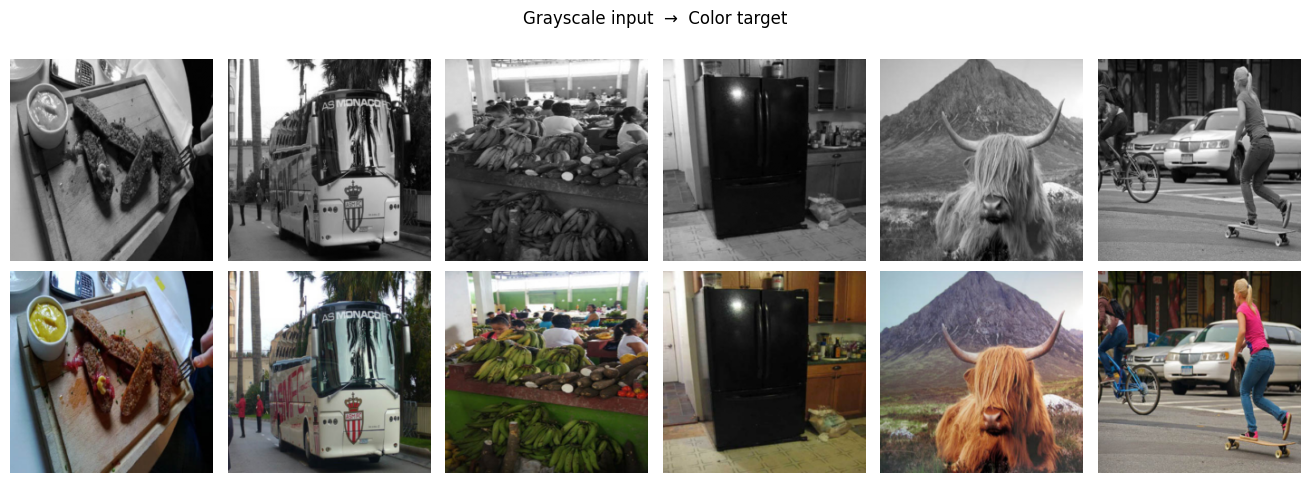

In [24]:
def show_pairs(gray_b, color_b, n=6):
    n = min(n, gray_b.size(0))
    fig, axes = plt.subplots(2, n, figsize=(2.2 * n, 5))
    for i in range(n):
        axes[0, i].imshow(gray_b[i, 0].cpu().numpy(), cmap="gray")
        axes[0, i].axis("off")
        axes[1, i].imshow(color_b[i].permute(1, 2, 0).cpu().numpy())
        axes[1, i].axis("off")
    axes[0, 0].set_ylabel("input (gray)")
    axes[1, 0].set_ylabel("target (color)")
    plt.suptitle("Grayscale input  →  Color target", y=0.98)
    plt.tight_layout()
    plt.show()

show_pairs(gray_batch, color_batch, n=6)